In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Load the Dataset
# Load clinical data
clinical_train = pd.read_csv('raw_data/X_train/clinical_train.csv')
clinical_test = pd.read_csv('raw_data/X_test/clinical_test.csv')

# Load molecular data
molecular_train = pd.read_csv('raw_data/X_train/molecular_train.csv')
molecular_test = pd.read_csv('raw_data/X_test/molecular_test.csv')

# Load target
target_train = pd.read_csv('raw_data/target_train.csv')

print("Clinical train shape:", clinical_train.shape)
print("Molecular train shape:", molecular_train.shape)
print("Target train shape:", target_train.shape)

Clinical train shape: (3323, 9)
Molecular train shape: (10935, 11)
Target train shape: (3323, 3)


In [3]:
# Data Overview and Summary Statistics
print("=== CLINICAL DATA ===")
print("Shape:", clinical_train.shape)
print("\nData Types:")
print(clinical_train.dtypes.value_counts())
print("\nFirst 5 rows:")
display(clinical_train.head())
print("\nSummary Statistics:")
display(clinical_train.describe())

print("\n=== MOLECULAR DATA ===")
print("Shape:", molecular_train.shape)
print("\nData Types:")
print(molecular_train.dtypes.value_counts())
print("\nFirst 5 rows:")
display(molecular_train.head())
print("\nSummary Statistics:")
display(molecular_train.describe())

print("\n=== TARGET DATA ===")
print("Shape:", target_train.shape)
print("\nData Types:")
print(target_train.dtypes)
print("\nFirst 5 rows:")
display(target_train.head())
print("\nSummary Statistics:")
display(target_train.describe())

=== CLINICAL DATA ===
Shape: (3323, 9)

Data Types:
float64    6
object     3
Name: count, dtype: int64

First 5 rows:


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"



Summary Statistics:


,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT
count,3214.000000,3051.000000,3130.000000,2722.000000,3213.000000,3199.000000
mean,5.982545,6.535164,3.264735,0.955868,9.893549,167.048900
std,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031
min,0.000000,0.200000,0.000000,0.000000,4.000000,2.000000
25%,1.000000,2.700000,1.000000,0.150000,8.500000,65.500000
50%,3.000000,4.100000,2.000000,0.370000,9.700000,123.000000
75%,8.000000,6.655000,3.690000,0.783000,11.200000,229.500000
max,91.000000,154.400000,109.620000,44.200000,16.600000,1451.000000



=== MOLECULAR DATA ===
Shape: (10935, 11)

Data Types:
object     7
float64    4
Name: count, dtype: int64

First 5 rows:


...

,START,END,VAF,DEPTH
count,1.082100e+04,1.082100e+04,10846.000000,10821.000000
mean,8.078326e+07,8.078326e+07,0.305087,1051.229554
std,5.642656e+07,5.642656e+07,0.211524,552.861902
min,3.948990e+05,3.948990e+05,0.020000,16.000000
25%,3.102244e+07,3.102244e+07,0.102625,660.000000
50%,7.473296e+07,7.473296e+07,0.321250,975.000000
75%,1.152587e+08,1.152587e+08,0.442000,1353.000000
max,2.262521e+08,2.262521e+08,0.999000,7156.000000



=== TARGET DATA ===
Shape: (3323, 3)

Data Types:
ID            object
OS_YEARS     float64
OS_STATUS    float64
dtype: object

First 5 rows:


,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0



Summary Statistics:


,OS_YEARS,OS_STATUS
count,3173.000000,3173.000000
mean,2.480713,0.504255
std,2.588259,0.500061
min,0.000000,0.000000
25%,0.652055,0.000000
50%,1.652055,1.000000
75%,3.572603,1.000000
max,22.043836,1.000000


=== MISSING VALUES ANALYSIS ===
Clinical data missing values:
BM_BLAST: 109 (3.28%)
WBC: 272 (8.19%)
ANC: 193 (5.81%)
MONOCYTES: 601 (18.09%)
HB: 110 (3.31%)
PLT: 124 (3.73%)
CYTOGENETICS: 387 (11.65%)

Molecular data missing values:
CHR: 114 (1.04%)
START: 114 (1.04%)
END: 114 (1.04%)
REF: 114 (1.04%)
ALT: 114 (1.04%)
PROTEIN_CHANGE: 12 (0.11%)
VAF: 89 (0.81%)
DEPTH: 114 (1.04%)

Target missing values: 300


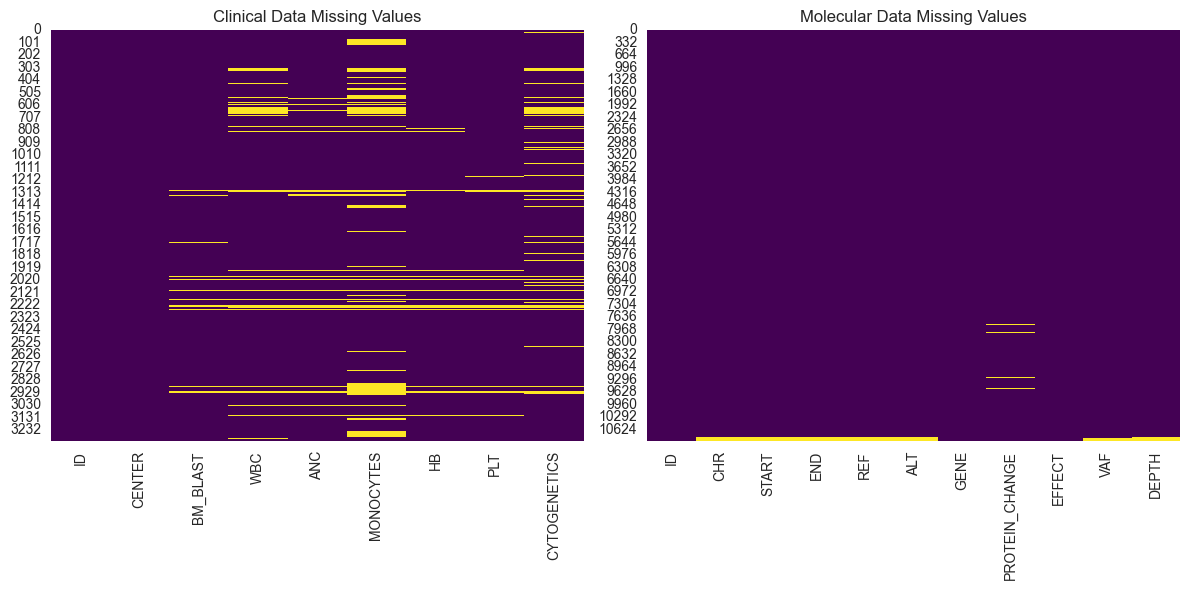

In [4]:
# Handle Missing Values
print("=== MISSING VALUES ANALYSIS ===")

# Clinical data missing values
clinical_missing = clinical_train.isnull().sum()
clinical_missing_pct = (clinical_missing / len(clinical_train)) * 100

print("Clinical data missing values:")
for col, count in clinical_missing[clinical_missing > 0].items():
    print(f"{col}: {count} ({clinical_missing_pct[col]:.2f}%)")

# Molecular data missing values
molecular_missing = molecular_train.isnull().sum()
molecular_missing_pct = (molecular_missing / len(molecular_train)) * 100

print("\nMolecular data missing values:")
for col, count in molecular_missing[molecular_missing > 0].items():
    print(f"{col}: {count} ({molecular_missing_pct[col]:.2f}%)")

# Target missing values
target_missing = target_train.isnull().sum()
print(f"\nTarget missing values: {target_missing.sum()}")

# Visualize missing values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(clinical_train.isnull(), cbar=False, cmap='viridis')
plt.title('Clinical Data Missing Values')
plt.subplot(1, 2, 2)
sns.heatmap(molecular_train.isnull(), cbar=False, cmap='viridis')
plt.title('Molecular Data Missing Values')
plt.tight_layout()
plt.show()

In [5]:
# Data Visualization - Distributions
# Select clinical features excluding WBC due to multicollinearity
clinical_numeric = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']

fig = make_subplots(rows=3, cols=2, subplot_titles=clinical_numeric + ['Survival Time'])

# Histograms for clinical features
for i, col in enumerate(clinical_numeric):
    row = (i // 2) + 1
    col_pos = (i % 2) + 1
    fig.add_trace(go.Histogram(x=clinical_train[col].dropna(), name=col), row=row, col=col_pos)

# Survival time distribution
fig.add_trace(go.Histogram(x=target_train['OS_YEARS'].dropna(), name='Survival Time'), row=3, col=2)

fig.update_layout(height=800, title_text="Distributions of Clinical Features and Survival Time")
fig.show()



## Hypothèse sur les variables exclues

À partir de cette section de l'analyse exploratoire, nous excluons les variables **CENTER**, **CYTOGENETICS** et **WBC** des variables cliniques considérées.

**Hypothèse :** Nous négligeons l'impact prédictif de CENTER, CYTOGENETICS et WBC sur la survie des patients, en nous concentrant uniquement sur les variables numériques cliniques restantes (BM_BLAST, ANC, MONOCYTES, HB, PLT) pour simplifier l'analyse et nous focaliser sur les marqueurs biologiques quantitatifs non redondants.

**Raison pour exclure WBC :** WBC présente une forte multicolinéarité avec ANC (corrélation = 0.847) et MONOCYTES (corrélation = 0.748), car ANC et MONOCYTES sont des composants de WBC. Retirer WBC évite les problèmes de stabilité dans les modèles prédictifs tout en conservant l'information plus spécifique apportée par ANC et MONOCYTES.

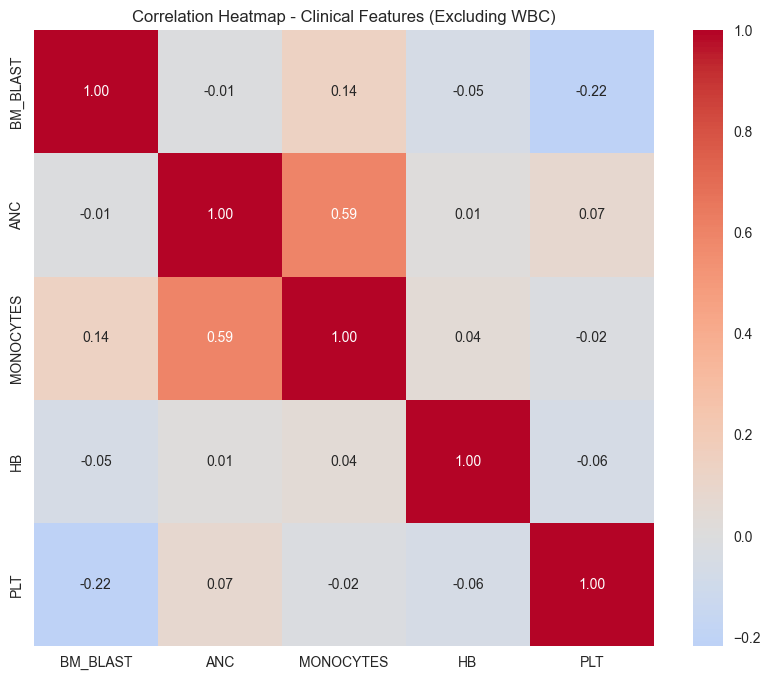

In [6]:
# Data Visualization - Relationships
# Correlation heatmap for clinical data (excluding WBC)
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']
clinical_corr = clinical_train[clinical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(clinical_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Clinical Features (Excluding WBC)')
plt.show()



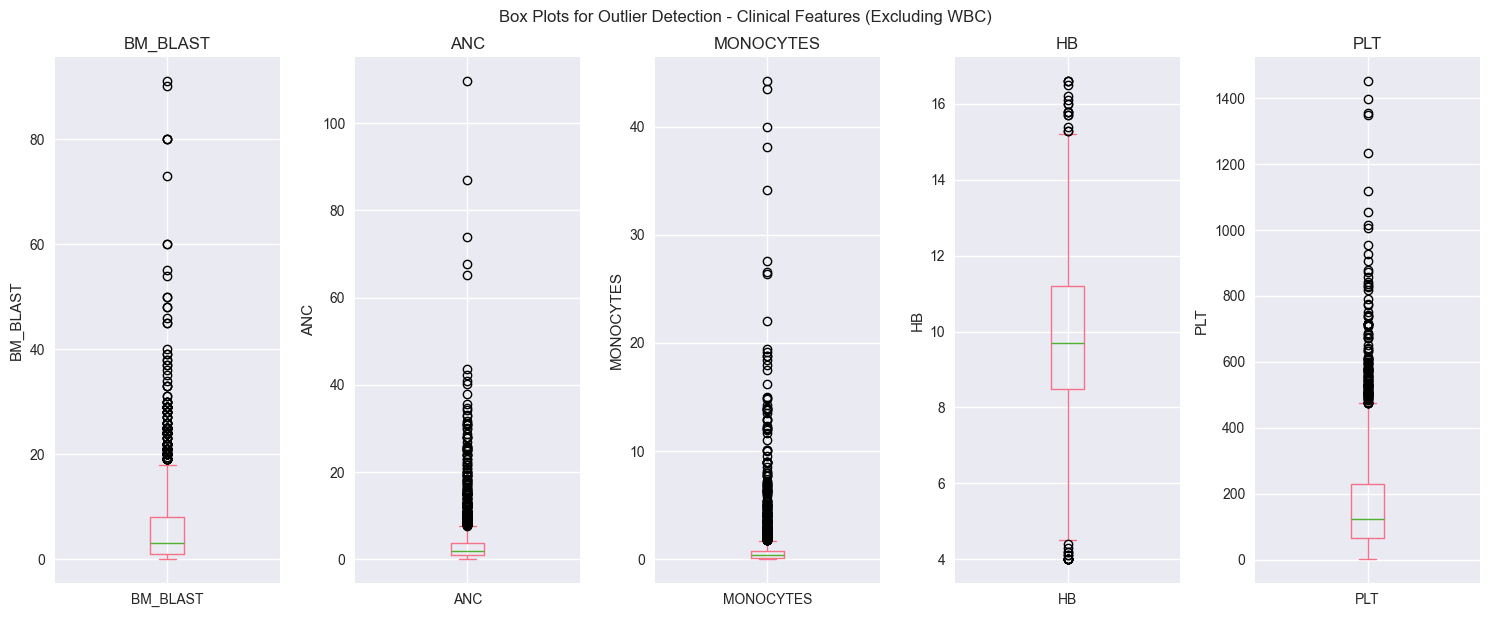

In [7]:
# Outlier Detection
# Using box plots to identify outliers in clinical data (excluding WBC)
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']

# Create subplots for each feature
fig, axes = plt.subplots(1, len(clinical_features), figsize=(15, 6))
for i, col in enumerate(clinical_features):
    clinical_train[col].dropna().plot(kind='box', ax=axes[i], title=col)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Box Plots for Outlier Detection - Clinical Features (Excluding WBC)', y=1.02)
plt.show()



Original vs Log-transformed Distributions:


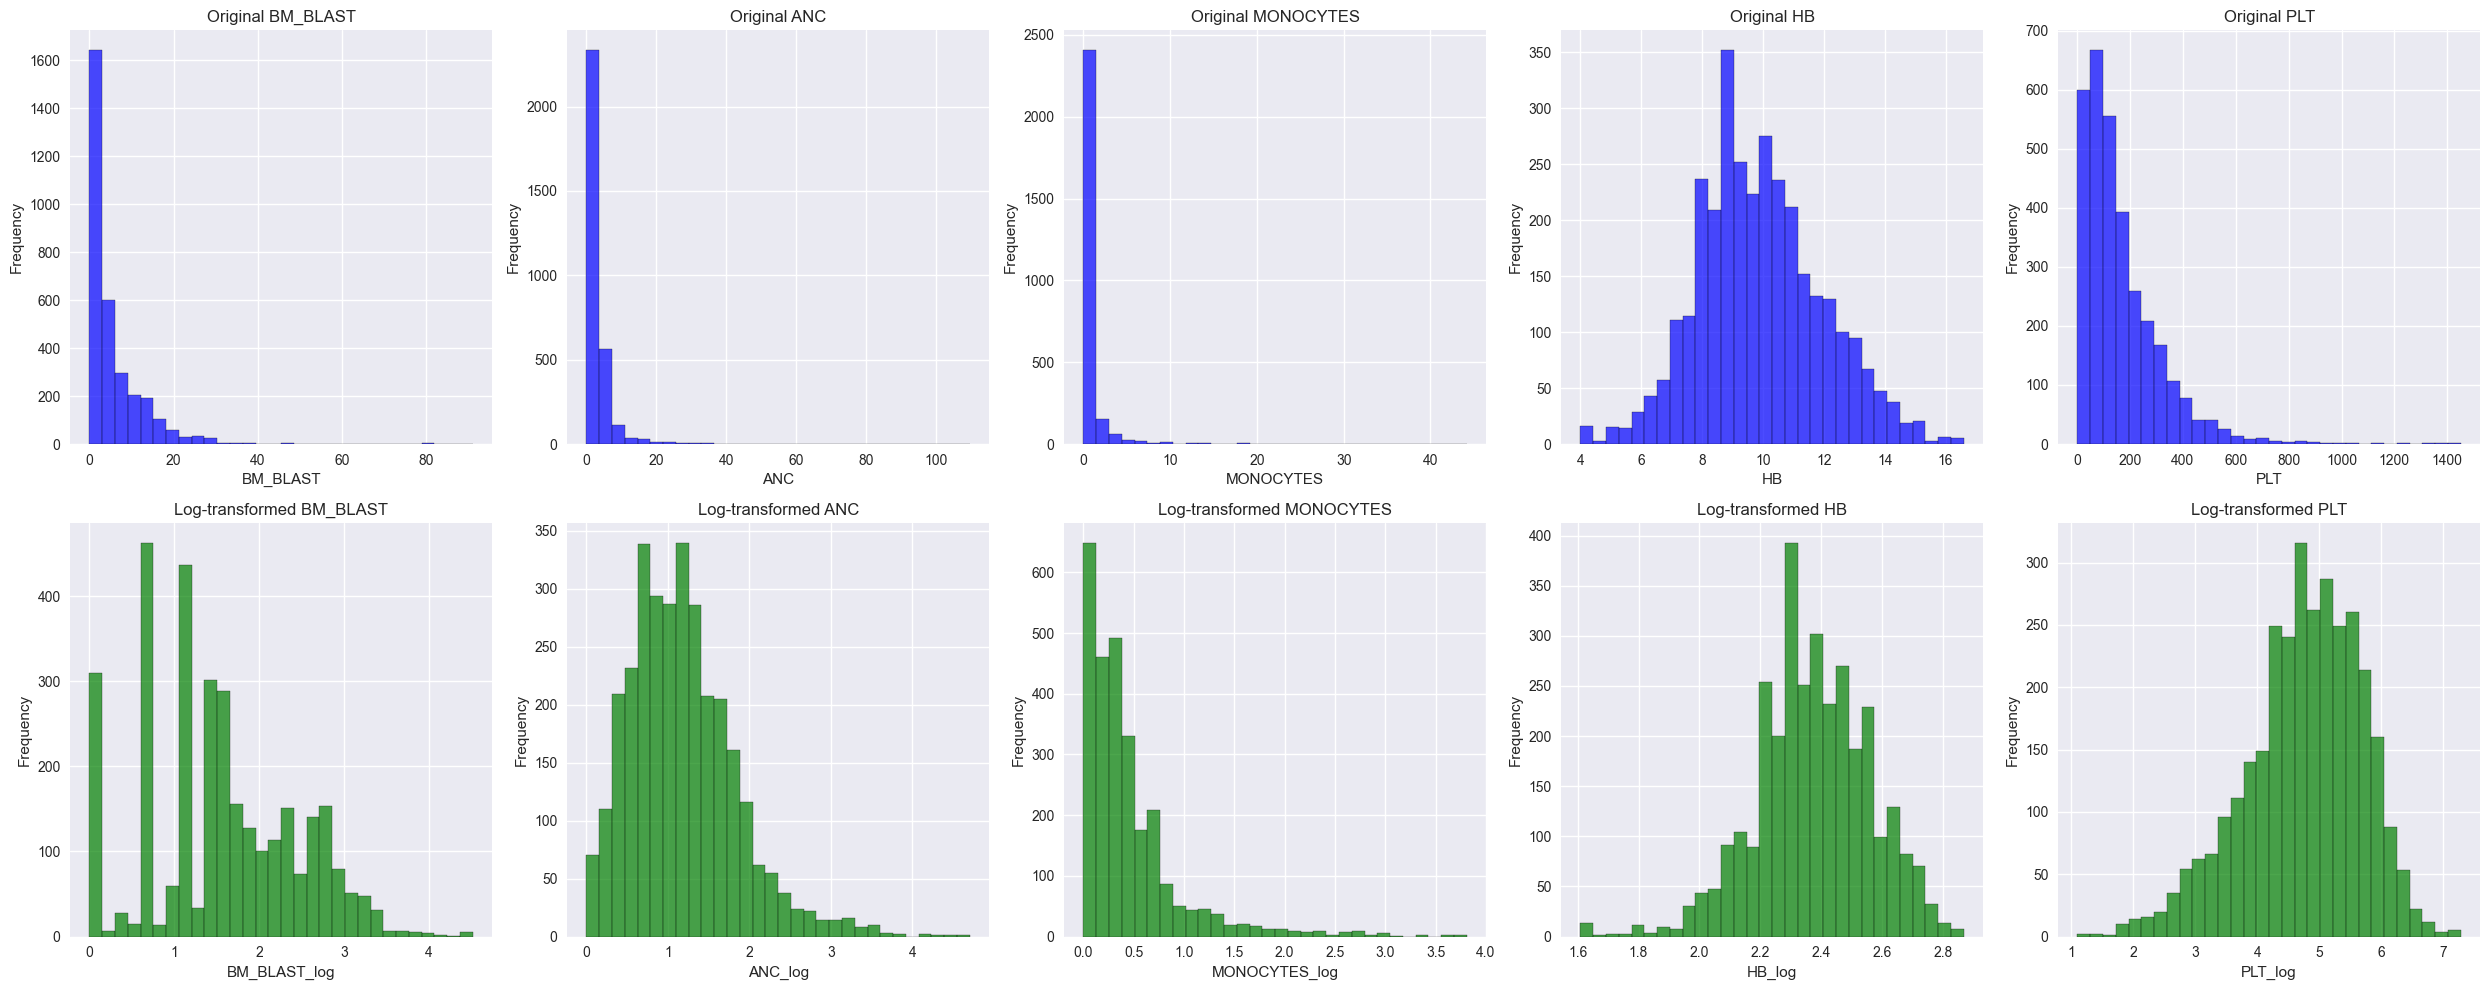


Box Plots After Log Transformation:


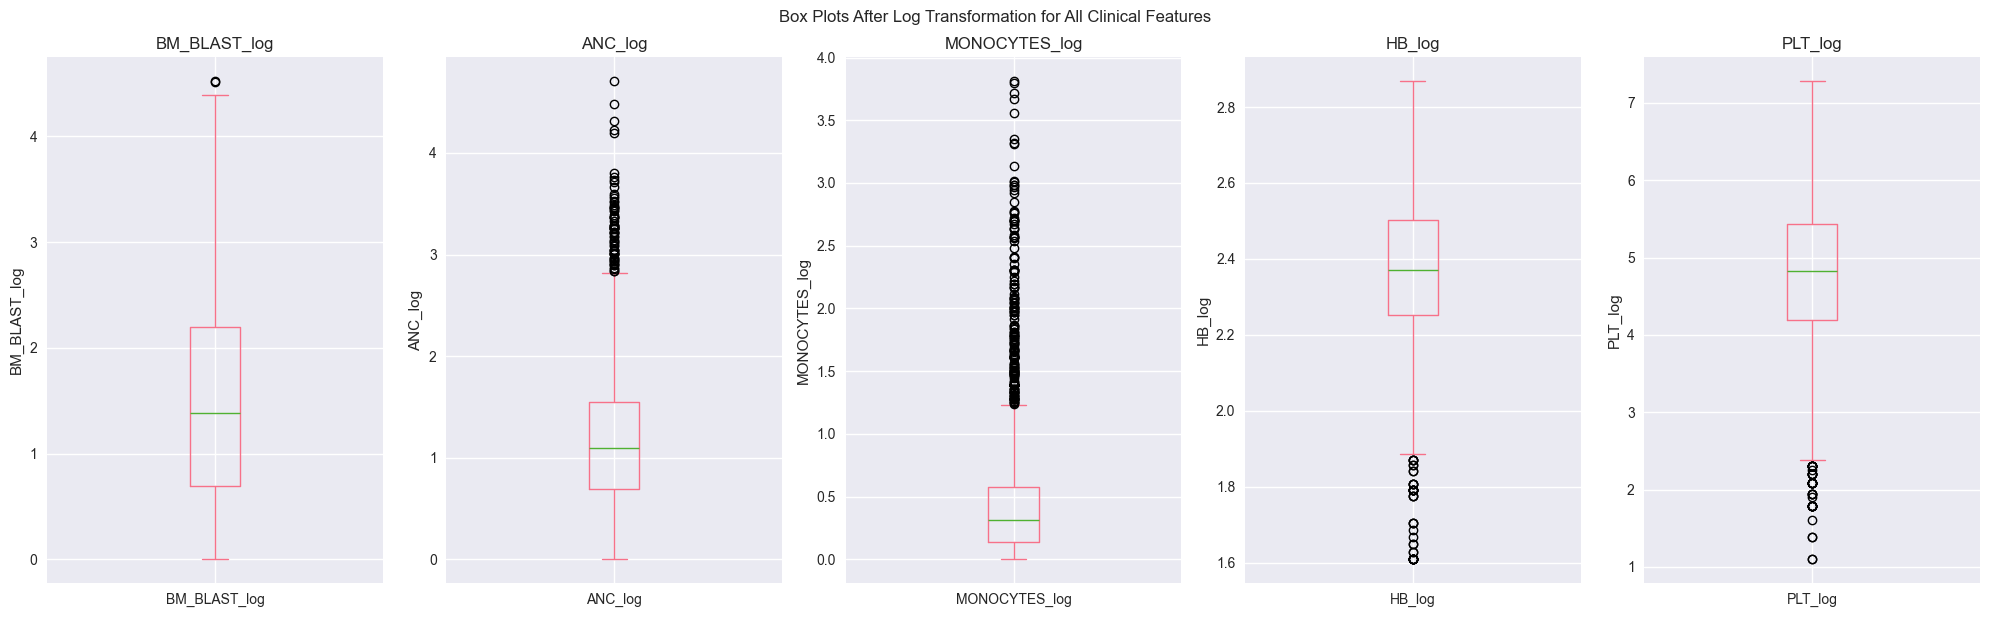

In [8]:
# Data Transformation - Log Transformation for All Clinical Variables
# Apply log(x + 1) transformation to all clinical features to reduce skewness
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']

# Create transformed dataframe
clinical_transformed = clinical_train.copy()
for col in clinical_features:
    clinical_transformed[f'{col}_log'] = np.log1p(clinical_train[col])

print("Original vs Log-transformed Distributions:")
fig, axes = plt.subplots(2, len(clinical_features), figsize=(25, 10))

for i, col in enumerate(clinical_features):
    # Original
    axes[0, i].hist(clinical_train[col].dropna(), bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0, i].set_title(f'Original {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    
    # Transformed
    axes[1, i].hist(clinical_transformed[f'{col}_log'].dropna(), bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1, i].set_title(f'Log-transformed {col}')
    axes[1, i].set_xlabel(f'{col}_log')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots after transformation
print("\nBox Plots After Log Transformation:")
fig, axes = plt.subplots(1, len(clinical_features), figsize=(20, 6))
for i, col in enumerate(clinical_features):
    clinical_transformed[f'{col}_log'].dropna().plot(kind='box', ax=axes[i], title=f'{col}_log')
    axes[i].set_ylabel(f'{col}_log')

plt.tight_layout()
plt.suptitle('Box Plots After Log Transformation for All Clinical Features', y=1.02)
plt.show()

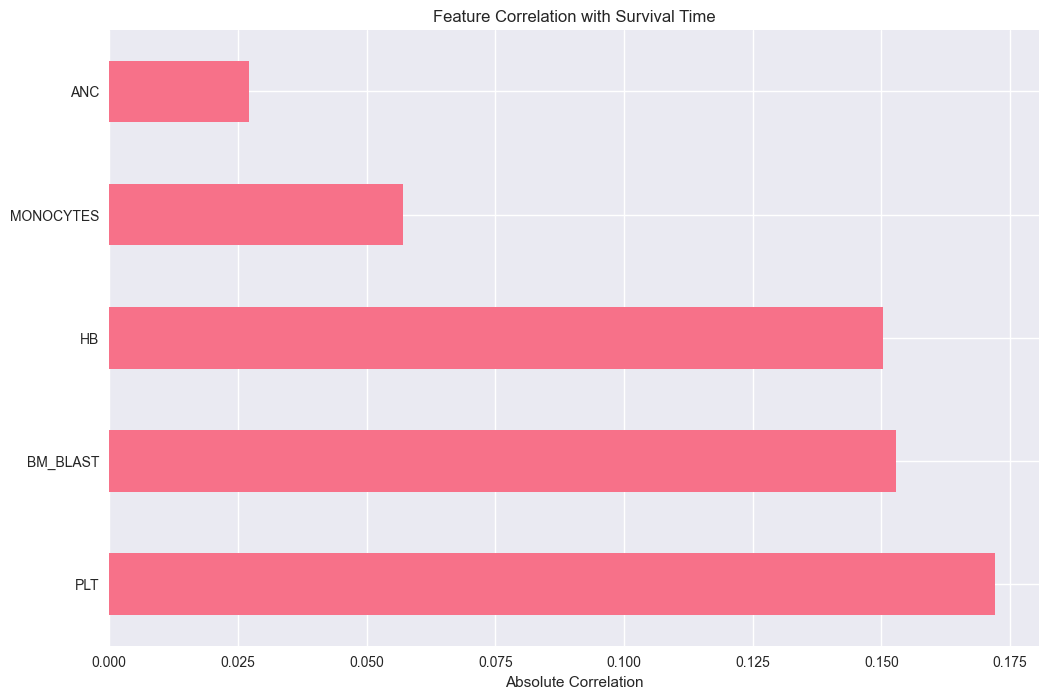

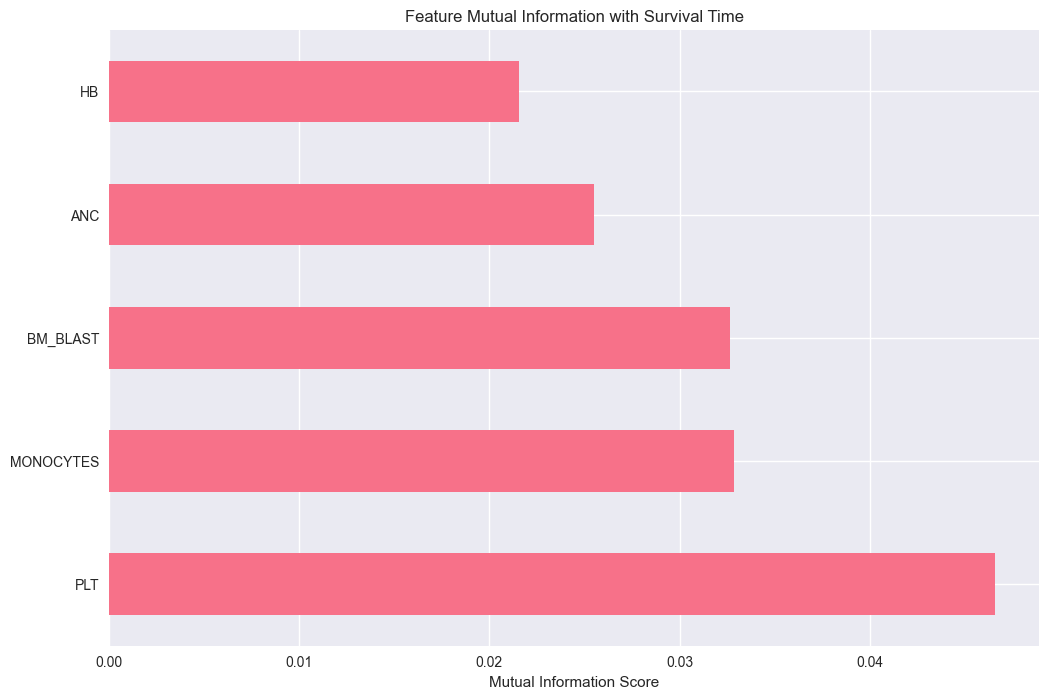

In [9]:
# Feature Importance Analysis
# Correlation with survival time (excluding WBC)
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']
survival_corr = pd.concat([clinical_train[clinical_features], target_train['OS_YEARS']], axis=1).corr()['OS_YEARS'].drop('OS_YEARS').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
survival_corr.plot(kind='barh')
plt.title('Feature Correlation with Survival Time')
plt.xlabel('Absolute Correlation')
plt.show()

# Mutual information for feature importance (if sklearn available)

from sklearn.feature_selection import mutual_info_regression

# Prepare data
clinical_clean = clinical_train[clinical_features].dropna()
target_clean = target_train.loc[clinical_clean.index, 'OS_YEARS'].dropna()
clinical_clean = clinical_clean.loc[target_clean.index]

mi_scores = mutual_info_regression(clinical_clean, target_clean)
mi_scores = pd.Series(mi_scores, index=clinical_clean.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
mi_scores.plot(kind='barh')
plt.title('Feature Mutual Information with Survival Time')
plt.xlabel('Mutual Information Score')
plt.show()
    

